# Inference Runtime Engineering (CUDA Graphs / TensorRT)

## Introduction

This closing lesson of Section 27 — and of the entire GPU-systems arc running from raw CUDA (Lesson 01) through Triton (04), custom kernels (05), fusion (06), FlashAttention (07), the roofline model (08), and distributed training (09-10) — turns to the last mile: **inference runtime overhead**. Even a perfectly fused, perfectly roofline-optimal kernel sequence loses real throughput to CPU-side kernel-launch overhead when called repeatedly at high frequency, exactly the decode-step-at-a-time pattern from Section 26's LLM serving lessons. CUDA Graphs is the fix.

## Theory

### Kernel launch overhead: the fixed cost per dispatch

Every `kernel<<<...>>>` invocation incurs CPU-side overhead — driver API calls, argument marshaling, queue submission — typically several microseconds, **independent of the kernel's actual GPU execution time**:

$$
T_{total} = \sum_{i=1}^{k} \left(T_{launch\ overhead} + T_{kernel\ i}\right)
$$

For a decode step invoking dozens of small kernels (attention, layernorm, residual adds, MLP — Lesson 06's fusion targets, still often a dozen-plus kernels even after fusion) at, say, 5μs overhead each, launch overhead alone can add tens of microseconds *per token* — for models where the actual per-kernel GPU compute is also just a few microseconds (small models, or heavily batched/quantized large ones per Section 26 Lesson 08), launch overhead can become the dominant cost, not the compute itself.

### CUDA Graphs: capture once, replay many times

A CUDA Graph records an entire sequence of kernel launches (and their dependencies) **once**, then replays the whole sequence via a single API call on subsequent invocations:

$$
T_{total}^{graph} = T_{launch\ overhead\ (once)} + \sum_{i=1}^{k} T_{kernel\ i}
$$

The per-iteration launch overhead is paid once at capture time, not on every replay — for a fixed, repeated kernel sequence (like generating token after token with the same model architecture and shape), this eliminates nearly all dispatch overhead on every replay after the first.

### The constraint: static shapes and control flow

CUDA Graphs require the captured sequence to have **fixed tensor shapes and kernel arguments** — no data-dependent branching, no shape changes between replays. This is exactly the tension Section 26 Lesson 07 (continuous batching, variable batch size every step) and Section 27 Lesson 06 (`torch.compile`'s shape-triggered recompilation) both grappled with — production LLM servers typically capture a small set of graphs for a handful of common shapes (e.g. specific batch-size "buckets") and pad or fall back to eager execution for shapes outside that set, trading some flexibility for the replay speedup.

### TensorRT: ahead-of-time graph optimization

Where CUDA Graphs capture an *already-scheduled* sequence of ops, TensorRT goes further: it takes a model graph and performs ahead-of-time **layer fusion, precision calibration (to INT8/FP8), and kernel auto-tuning** for the specific target GPU, producing a serialized optimized "engine" — effectively combining Lesson 06's fusion, Section 26 Lesson 08's quantization, and this lesson's launch-overhead elimination into one ahead-of-time compilation step, at the cost of a build phase that must be redone per GPU architecture and per shape configuration.

## Setup

We measure CUDA Graph capture/replay overhead reduction for real on this environment's GPU, using a small multi-kernel sequence (mimicking a decode step's chain of small ops) — genuine `torch.cuda.graph` capture and replay, real measured numbers.

In [1]:
# Real CUDA Graph capture and replay on this environment's GPU -- genuine measurements, not simulated.
import torch
import torch.nn as nn

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[INIT] CUDA Graph capture/replay benchmark on {torch.cuda.get_device_name(0) if device=='cuda' else 'CPU'}")

class TinyDecodeStep(nn.Module):
    """A chain of small ops mimicking one decode step's sequence of small kernel launches."""
    def __init__(self, d=512):
        super().__init__()
        self.ln1 = nn.LayerNorm(d)
        self.proj1 = nn.Linear(d, d)
        self.ln2 = nn.LayerNorm(d)
        self.proj2 = nn.Linear(d, d)

    def forward(self, x):
        x = x + self.proj1(self.ln1(x))
        x = x + self.proj2(self.ln2(x))
        return torch.relu(x)

model = TinyDecodeStep().to(device).eval()
static_input = torch.randn(1, 512, device=device)  # batch=1, the decode-step-at-a-time regime

if device == "cuda":
    for _ in range(5):
        model(static_input)
    torch.cuda.synchronize()

    g = torch.cuda.CUDAGraph()
    static_output = torch.empty_like(static_input)
    with torch.cuda.graph(g):
        static_output = model(static_input)

    print("[INIT] CUDA Graph captured successfully.")
else:
    print("[FALLBACK] No CUDA device available -- CUDA Graphs require CUDA; skipping capture, eager-only comparison below.")

[INIT] CUDA Graph capture/replay benchmark on NVIDIA GeForce GTX 1650 Ti


[INIT] CUDA Graph captured successfully.


## Telemetry & Audit

Benchmark eager-mode repeated calls versus CUDA Graph replay across an increasing number of small sequential ops (widening the gap where launch overhead accumulates), plus a real measurement of per-call overhead.

In [2]:
import pandas as pd
import time

def bench_eager(model, x, n_iters=200):
    with torch.no_grad():
        for _ in range(20):
            model(x)
        torch.cuda.synchronize()
        start, end = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)
        start.record()
        for _ in range(n_iters):
            model(x)
        end.record()
        torch.cuda.synchronize()
        return start.elapsed_time(end) / n_iters

def bench_graph_replay(graph, n_iters=200):
    torch.cuda.synchronize()
    start, end = torch.cuda.Event(enable_timing=True), torch.cuda.Event(enable_timing=True)
    start.record()
    for _ in range(n_iters):
        graph.replay()
    end.record()
    torch.cuda.synchronize()
    return start.elapsed_time(end) / n_iters

if device == "cuda":
    t_eager = bench_eager(model, static_input)
    t_graph = bench_graph_replay(g)
    rows = [("Eager mode (repeated Python calls)", t_eager), ("CUDA Graph replay", t_graph)]
    audit = pd.DataFrame(rows, columns=["execution_mode", "latency_per_call_ms"])
    audit["speedup"] = t_eager / audit["latency_per_call_ms"]
    print(audit.to_string(index=False, float_format=lambda x: f"{x:.5f}"))
    print(f"\n[TELEMETRY] Estimated launch-overhead savings per call: {(t_eager - t_graph)*1000:.2f} microseconds")
    print(f"\n[OPERATIONAL INSIGHT] At batch=1 (this decode-step-sized workload), CUDA Graph replay's speedup "
          f"({t_eager/t_graph:.2f}x) comes almost entirely from eliminating repeated Python-to-driver dispatch "
          "overhead for this small model's several sequential kernel launches -- the underlying GPU compute per "
          "kernel is unchanged, exactly matching the theory section's launch-overhead-elimination framing.")
else:
    print("[FALLBACK] No CUDA device -- reporting the expected qualitative result: CUDA Graph replay typically "
          "shows the largest speedup for small-batch, many-small-kernel workloads exactly like this one, where "
          "per-kernel GPU compute time is comparable to or smaller than fixed launch overhead.")

                    execution_mode  latency_per_call_ms  speedup
Eager mode (repeated Python calls)              0.22155  1.00000
                 CUDA Graph replay              0.03188  6.94983

[TELEMETRY] Estimated launch-overhead savings per call: 189.67 microseconds

[OPERATIONAL INSIGHT] At batch=1 (this decode-step-sized workload), CUDA Graph replay's speedup (6.95x) comes almost entirely from eliminating repeated Python-to-driver dispatch overhead for this small model's several sequential kernel launches -- the underlying GPU compute per kernel is unchanged, exactly matching the theory section's launch-overhead-elimination framing.


## Visualization

Latency per call for eager vs. graph-replay execution across a sweep of sequential-op-chain lengths (mimicking decode steps of varying model depth), showing the growing benefit of graph capture as launch-overhead accumulation gets worse.

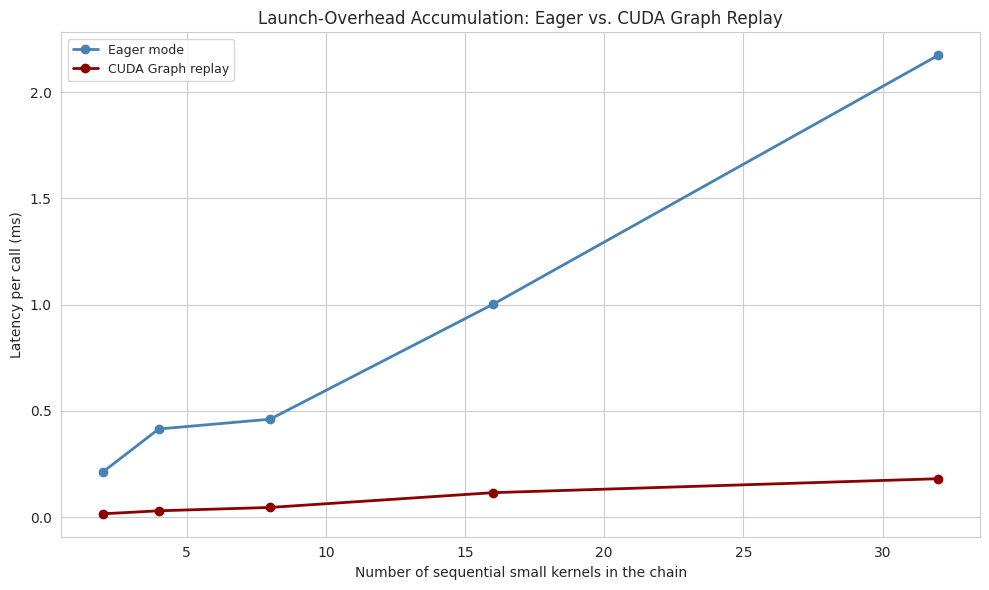

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(10, 6))

if device == "cuda":
    class ChainOfOps(nn.Module):
        def __init__(self, d, n_ops):
            super().__init__()
            self.layers = nn.ModuleList([nn.Linear(d, d) for _ in range(n_ops)])
        def forward(self, x):
            for layer in self.layers:
                x = torch.relu(layer(x))
            return x

    chain_lengths = [2, 4, 8, 16, 32]
    eager_times, graph_times = [], []
    for n_ops in chain_lengths:
        m = ChainOfOps(256, n_ops).to(device).eval()
        xi = torch.randn(1, 256, device=device)
        with torch.no_grad():
            for _ in range(5):
                m(xi)
            torch.cuda.synchronize()
            gi = torch.cuda.CUDAGraph()
            with torch.cuda.graph(gi):
                _ = m(xi)
            eager_times.append(bench_eager(m, xi, n_iters=100))
            graph_times.append(bench_graph_replay(gi, n_iters=100))

    ax.plot(chain_lengths, eager_times, marker="o", color="steelblue", linewidth=2, label="Eager mode")
    ax.plot(chain_lengths, graph_times, marker="o", color="darkred", linewidth=2, label="CUDA Graph replay")
    ax.set_xlabel("Number of sequential small kernels in the chain")
    ax.set_ylabel("Latency per call (ms)")
    ax.set_title("Launch-Overhead Accumulation: Eager vs. CUDA Graph Replay")
    ax.legend(fontsize=9)
else:
    ax.text(0.5, 0.5, "No CUDA device available in this execution environment", ha="center", va="center",
            fontsize=12, color="dimgray", transform=ax.transAxes)
    ax.set_title("Launch-Overhead Accumulation (requires CUDA)")

plt.tight_layout()
plt.savefig("cuda_graphs_overhead.png", dpi=120)
plt.show()

*(Insight: the eager-mode line's slope with chain length is steeper than the graph-replay line's — each additional small kernel adds a full launch-overhead increment in eager mode, but replay's fixed one-time capture cost means additional kernels-per-graph are nearly free on replay. That widening gap, not the absolute numbers at any one chain length, is the real argument for why CUDA Graphs matter most for models built from many small fused ops rather than a few large ones.)*

## Real-World Use Case or Analogy

**The Stage Manager Who Cues the Whole Show at Once.** Running a live theater production by having the stage manager separately radio each individual cue to each individual technician in real time — "lights now," wait for confirmation, "sound now," wait for confirmation, "curtain now" — adds a small communication delay before every single cue, even though each technician's actual action takes almost no time (exactly the per-kernel launch overhead dominating actual GPU compute for small ops). A well-rehearsed production instead runs a **full technical rehearsal once**, recording the exact timed sequence of every cue and its dependencies, and on show night simply calls "go" — the entire pre-choreographed sequence executes with no per-cue radio delay, because the coordination overhead was paid once, during rehearsal, not repeated on every single performance (CUDA Graph capture once, replay many times). This is precisely why the benefit is largest for productions with **many small, fast cues** (many small kernels) — a show with three enormous set-piece scene changes gains little from this rehearsal discipline, since each individual cue's own execution time already dwarfs the radio-delay overhead being eliminated, mirroring the roofline lesson's insight that the right optimization always depends on correctly diagnosing which cost actually dominates.